Работаю с Brazilian e-commerce Olist. Дневные продажи там рваные, поэтому перехожу к неделям. Так меньше случайного шума и понятнее, где цена правда связана со спросом

In [ ]:

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import os

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

HW_RANDOM_STATE = 8
np.random.seed(HW_RANDOM_STATE)


def load_olist_pricing_data():
    base_url = 'https://raw.githubusercontent.com/MLinside-team/ML-in-business/main/datasets/pricing_Brazilian-E-Commerce-Public-Dataset-by-Olist/'
    orders_hw = pd.read_csv(
        base_url + 'ecommerce-sales-orders.csv.zip',
        compression='zip',
        parse_dates=['date']
    )
    order_items_hw = pd.read_csv(
        base_url + 'ecommerce-sales-order-items.csv.zip',
        compression='zip'
    )
    items_hw = pd.read_csv(
        base_url + 'ecommerce-sales-products.csv.zip',
        compression='zip'
    )

    orders_hw['date'] = pd.to_datetime(orders_hw['date'].dt.date)
    daily_hw = order_items_hw.merge(orders_hw, on='order_id', how='inner')
    daily_hw['sales_units'] = 1
    daily_hw = daily_hw.groupby(['product_id', 'date']).agg(
        price=('price', 'mean'),
        sales_units=('sales_units', 'sum')
    ).reset_index()
    return daily_hw, items_hw


daily_hw, items_hw = load_olist_pricing_data()

daily_hw['price'] = daily_hw['price'].round(2)

hw_weekly = daily_hw.copy()
hw_weekly['date'] = pd.to_datetime(hw_weekly['date']).dt.to_period('W').dt.start_time
hw_weekly = hw_weekly.groupby(['product_id', 'date']).agg(
    sales_units=('sales_units', 'sum'),
    price=('price', 'mean')
).reset_index()
hw_weekly['price'] = hw_weekly['price'].round(2)

hw_weekly = hw_weekly.merge(
    items_hw[['product_id', 'category_id']],
    on='product_id',
    how='left'
)
hw_weekly['category_id'] = hw_weekly['category_id'].fillna(-1).astype(int)

hw_pool = hw_weekly.groupby('product_id').agg(
    n_weeks=('date', 'nunique'),
    n_prices=('price', 'nunique'),
    total_units=('sales_units', 'sum'),
    avg_price=('price', 'mean'),
    category_id=('category_id', 'first')
).query('n_weeks >= 15 and n_prices >= 10 and total_units >= 20')

print('Товаров-кандидатов с 15+ неделями, 10+ ценами и 20+ продажами:', len(hw_pool))
hw_pool.sort_values(['n_prices', 'n_weeks', 'total_units'], ascending=False).head(10)


Товаров-кандидатов с 15+ неделями, 10+ ценами и 20+ продажами: 40


,n_weeks,n_prices,total_units,avg_price,category_id
product_id,,,,,
249,50,28,194,173.892800,25
103,41,26,323,135.436585,25
832,47,24,146,146.299574,25
884,31,21,123,307.452903,25
101,36,20,141,93.078611,12
1872,28,20,117,176.058214,25
2799,27,19,88,147.093704,12
1030,26,19,104,116.310769,25
150,32,18,183,87.018750,12


## Выбор товаров и эластичность

Сначала считаю простую log-log модель на неделях с продажами:

$$\log(1 + q_t) = \alpha + \varepsilon \log(p_t) + u_t$$

Коэффициент при log(price) читаю как первую оценку эластичности. Это грубая оценка, но для отбора она полезна: быстро видно, у каких товаров спрос падает при росте цены, а где связь почти пропала или выглядит странно.

Я не трактую этот коэффициент как чистый causal-эффект. Цена в Olist менялась не случайно. Продавец мог поднять цену в неделю высокого спроса, снизить ее перед распродажей или реагировать на остатки. Поэтому дальше я смотрю на знак, силу эффекта, p-value и саму кривую, а не на одно число.

In [2]:

def estimate_loglog_elasticity(data):
    d = data.dropna(subset=['sales_units', 'price']).copy()
    d = d[(d['price'] > 0) & (d['sales_units'] >= 0)]
    if d['price'].nunique() < 3 or len(d) < 8:
        return pd.Series({'elasticity': np.nan, 'pvalue': np.nan, 'r2': np.nan})

    d['log_price'] = np.log(d['price'])
    model = smf.ols('np.log1p(sales_units) ~ log_price', data=d).fit()
    return pd.Series({
        'elasticity': model.params.get('log_price', np.nan),
        'pvalue': model.pvalues.get('log_price', np.nan),
        'r2': model.rsquared
    })


elasticity_rows = []
for product_id in hw_pool.index:
    product_data = hw_weekly.query('product_id == @product_id')
    elasticity = estimate_loglog_elasticity(product_data)
    elasticity_rows.append({
        'product_id': product_id,
        **elasticity.to_dict(),
        **hw_pool.loc[product_id].to_dict()
    })

hw_candidates = pd.DataFrame(elasticity_rows).dropna(subset=['elasticity'])

# Берем товары с разным поведением: сильно отрицательная, умеренно отрицательная,
# слабая/нулевая и положительная наблюдаемая связь цены и спроса.
strong_negative = hw_candidates.query('elasticity < -1').sort_values(
    ['r2', 'n_prices'], ascending=False
).head(4)
moderate_or_weak = hw_candidates.query('-1 <= elasticity <= 0.4').sort_values(
    ['r2', 'n_prices'], ascending=[False, False]
).head(3)
positive_or_noisy = hw_candidates.query('elasticity > 0.4').sort_values(
    ['r2', 'n_prices'], ascending=False
).head(3)

selected_products = pd.concat(
    [strong_negative, moderate_or_weak, positive_or_noisy],
    ignore_index=True
).drop_duplicates('product_id').head(10)

if len(selected_products) < 8:
    selected_products = hw_candidates.sort_values(
        ['n_prices', 'n_weeks', 'total_units'], ascending=False
    ).head(10)

selected_products['elasticity_type'] = pd.cut(
    selected_products['elasticity'],
    bins=[-np.inf, -1.0, -0.4, 0.4, np.inf],
    labels=['сильно эластичный', 'умеренно эластичный', 'слабая связь', 'положительная/шумная связь']
)
selected_product_ids = selected_products['product_id'].tolist()
selected_products_summary = selected_products[[
    'product_id', 'category_id', 'n_weeks', 'n_prices', 'total_units',
    'avg_price', 'elasticity', 'pvalue', 'r2', 'elasticity_type'
]].sort_values('elasticity')

selected_products_summary


,product_id,category_id,n_weeks,n_prices,total_units,avg_price,elasticity,pvalue,r2,elasticity_type
2,2231,0.0,25.0,11.0,58.0,118.800800,-25.237665,0.003061,0.322568,сильно эластичный
1,884,25.0,31.0,21.0,123.0,307.452903,-1.980415,0.000811,0.325130,сильно эластичный
3,1872,25.0,28.0,20.0,117.0,176.058214,-1.847284,0.002090,0.309983,сильно эластичный
0,1142,25.0,18.0,14.0,63.0,123.178333,-1.225743,0.011818,0.335183,сильно эластичный
4,265,25.0,17.0,16.0,41.0,190.909412,-0.893722,0.027570,0.284157,умеренно эластичный
5,1364,52.0,24.0,12.0,48.0,204.120000,-0.813259,0.070195,0.141355,умеренно эластичный
6,1501,25.0,20.0,11.0,41.0,140.123000,-0.807774,0.112929,0.133660,умеренно эластичный
8,3626,3.0,27.0,11.0,89.0,109.717407,1.495327,0.054869,0.139621,положительная/шумная связь
7,6334,12.0,16.0,10.0,72.0,68.474375,2.397707,0.094450,0.186899,положительная/шумная связь
9,12,10.0,74.0,10.0,488.0,87.095135,4.233133,0.002619,0.118949,положительная/шумная связь


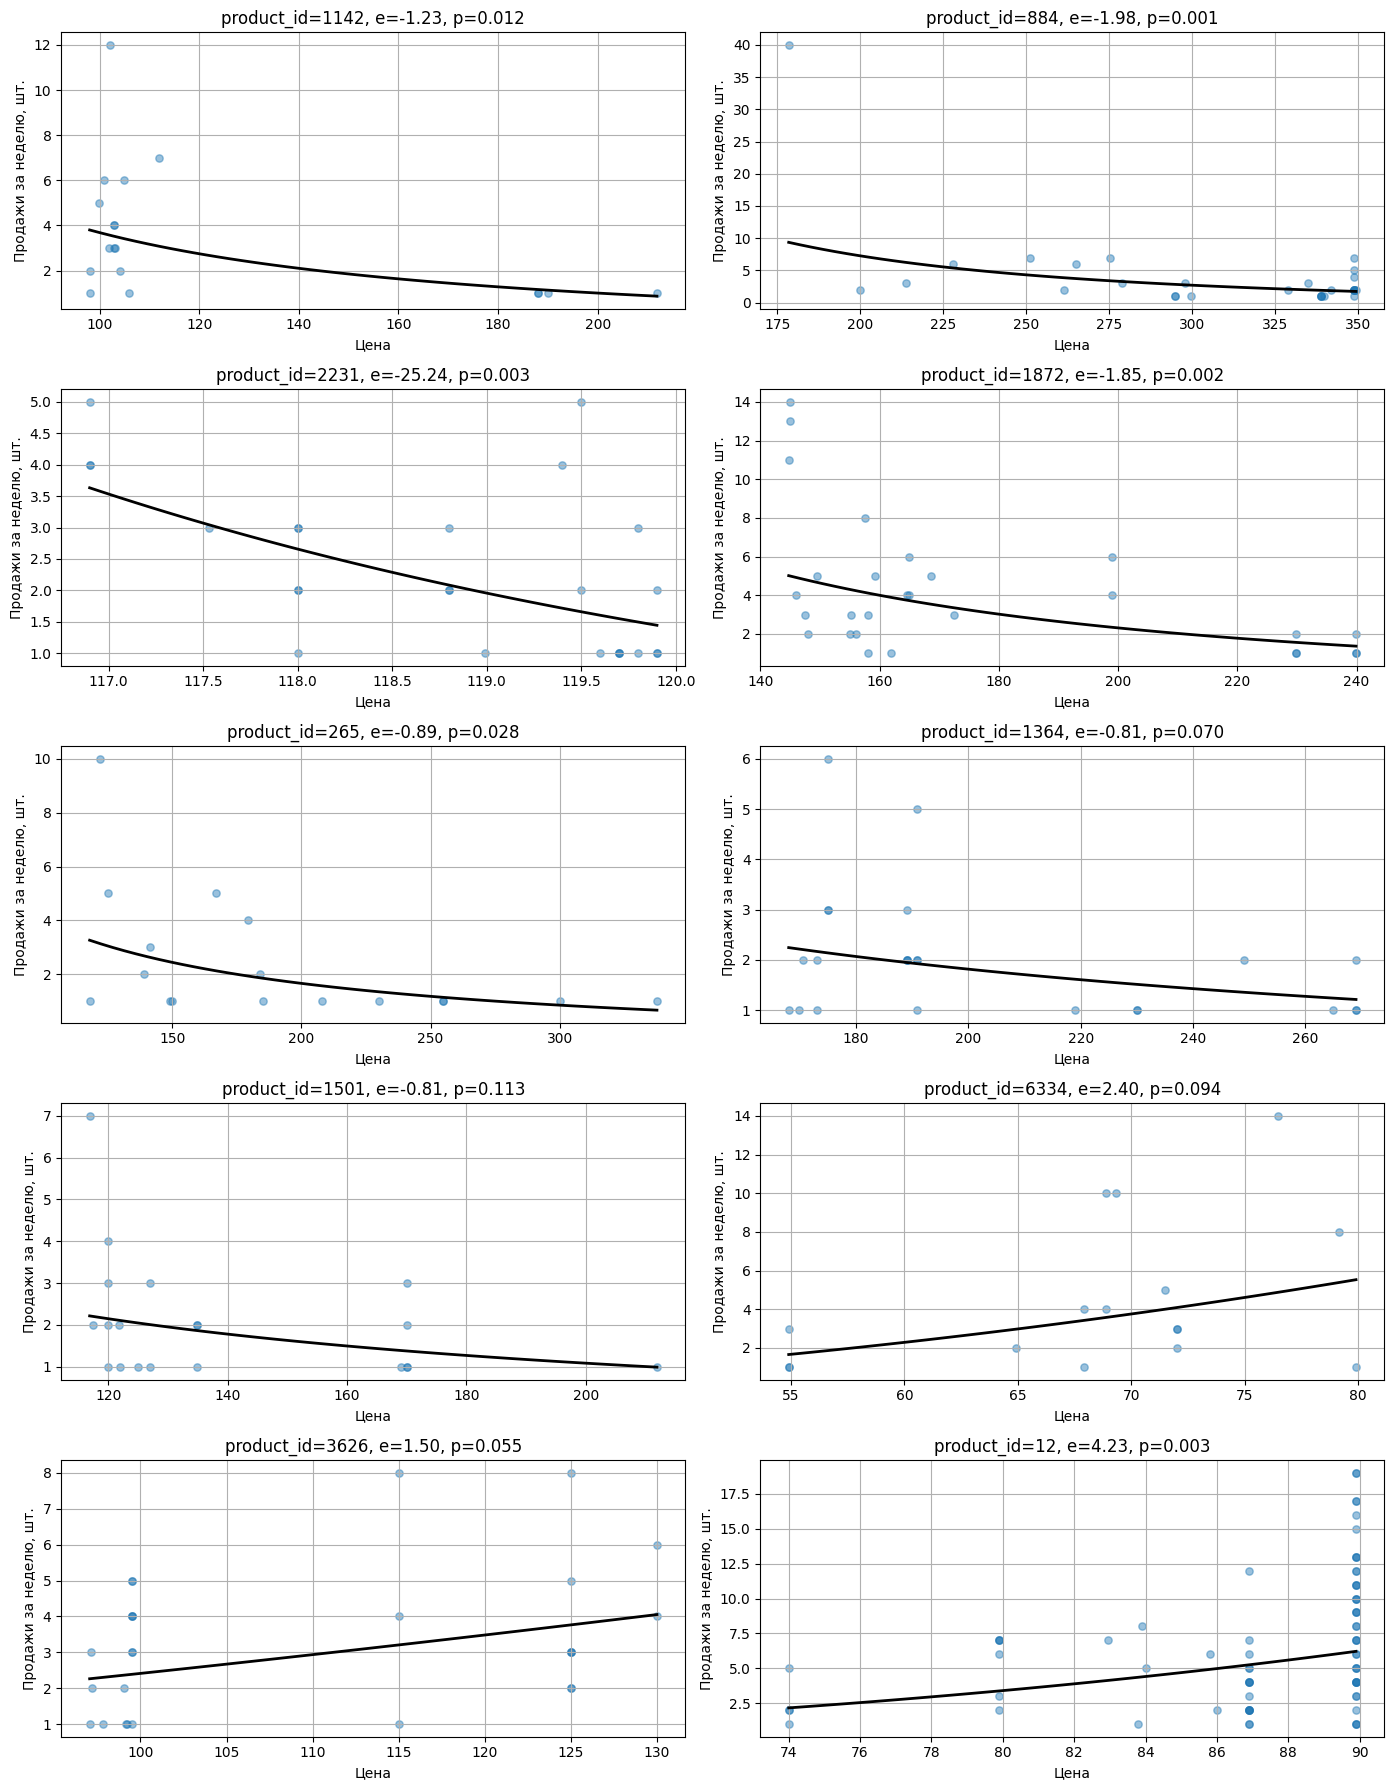

In [ ]:

fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharey=False)
axes = axes.ravel()

for ax, product_id in zip(axes, selected_product_ids):
    product_data = hw_weekly.query('product_id == @product_id').dropna(subset=['price']).copy()
    product_data = product_data[product_data['price'] > 0]
    product_data['log_price'] = np.log(product_data['price'])

    model = smf.ols('np.log1p(sales_units) ~ log_price', data=product_data).fit()
    price_grid = np.linspace(product_data['price'].min(), product_data['price'].max(), 50)
    curve_data = pd.DataFrame({'log_price': np.log(price_grid)})
    demand_hat = np.expm1(model.predict(curve_data)).clip(0)
    short_id = str(product_id)[:10]

    ax.scatter(product_data['price'], product_data['sales_units'], alpha=0.45, s=28)
    ax.plot(price_grid, demand_hat, color='black', linewidth=2)
    ax.set_title(
        f"product_id={short_id}, e={model.params['log_price']:.2f}, "
        f"p={model.pvalues['log_price']:.3f}"
    )
    ax.set_xlabel('Цена')
    ax.set_ylabel('Продажи за неделю, шт.')
    ax.grid(True)

for ax in axes[len(selected_product_ids):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


## Прогноз на holdout

Holdout - последние 20% недель каждого выбранного товара, минимум 4 недели. Разделяю train и test внутри каждого product_id, чтобы все товары остались в обеих частях выборки.

Сравниваю три варианта.

1. no_future_price - товар, категория, календарь и лаги продаж. Будущую цену модель не видит.
2. with_future_price - те же признаки плюс price, log(price) и изменение цены.
3. model_plus_curve - беру прогноз первой модели и домножаю его на ценовую поправку (future_price / reference_price) ** elasticity`.

Лаги продаж считаются только через shift, без текущих продаж. В test они используют фактические предыдущие недели, поэтому это one-step-ahead сценарий, а не полностью рекурсивный прогноз на весь holdout.

Третий вариант нарочно простой. Он показывает, насколько помогает отдельная кривая спроса, если не отдавать цену напрямую в бустинг

In [4]:

def make_complete_product_calendar(weekly_data, product_ids):
    frames = []
    for product_id in product_ids:
        d = weekly_data.query('product_id == @product_id').sort_values('date').copy()
        full_dates = pd.date_range(d['date'].min(), d['date'].max(), freq='W-MON')
        full = pd.DataFrame({'date': full_dates, 'product_id': product_id})
        full = full.merge(d, on=['product_id', 'date'], how='left')
        full['category_id'] = full['category_id'].ffill().bfill().fillna(-1).astype(int)
        full['sales_units'] = full['sales_units'].fillna(0)
        full['price'] = full['price'].ffill()
        full['price'] = full['price'].fillna(d['price'].median())
        frames.append(full)
    return pd.concat(frames, ignore_index=True)


hw_model_data = make_complete_product_calendar(hw_weekly, selected_product_ids)
hw_model_data = hw_model_data.sort_values(['product_id', 'date']).reset_index(drop=True)
hw_model_data['price_log'] = np.log(hw_model_data['price'])
hw_model_data['weekofyear'] = hw_model_data['date'].dt.isocalendar().week.astype(int)
hw_model_data['month'] = hw_model_data['date'].dt.month

for lag in [1, 2]:
    hw_model_data[f'sales_lag_{lag}'] = hw_model_data.groupby('product_id')['sales_units'].shift(lag)

hw_model_data['sales_roll_4'] = hw_model_data.groupby('product_id')['sales_units'].transform(
    lambda s: s.shift(1).rolling(4, min_periods=1).mean()
)
hw_model_data['price_lag_1'] = hw_model_data.groupby('product_id')['price'].shift(1)
hw_model_data['price_change'] = hw_model_data['price'] / hw_model_data['price_lag_1'] - 1

for col in ['sales_lag_1', 'sales_lag_2', 'sales_roll_4', 'price_lag_1', 'price_change']:
    hw_model_data[col] = hw_model_data.groupby('product_id')[col].transform(
        lambda s: s.fillna(s.median())
    )

split_parts = []
for product_id, product_data in hw_model_data.groupby('product_id'):
    product_data = product_data.sort_values('date').copy()
    n_holdout = max(4, int(np.ceil(len(product_data) * 0.20)))
    product_data['is_test'] = False
    product_data.loc[product_data.tail(n_holdout).index, 'is_test'] = True
    split_parts.append(product_data)

hw_model_data = pd.concat(split_parts, ignore_index=True)
hw_train = hw_model_data.query('is_test == False').copy()
hw_test = hw_model_data.query('is_test == True').copy()

categorical_features = ['product_id', 'category_id']
features_no_future_price = [
    'product_id', 'category_id', 'weekofyear', 'month',
    'sales_lag_1', 'sales_lag_2', 'sales_roll_4'
]
features_with_future_price = features_no_future_price + ['price', 'price_log', 'price_change']


def make_hw_regressor(features):
    numeric_features = [col for col in features if col not in categorical_features]
    preprocessing = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features)
    ])
    return Pipeline([
        ('preprocessing', preprocessing),
        ('model', HistGradientBoostingRegressor(
            max_iter=250,
            learning_rate=0.05,
            max_leaf_nodes=15,
            l2_regularization=0.05,
            random_state=HW_RANDOM_STATE
        ))
    ])


model_no_future_price = make_hw_regressor(features_no_future_price)
model_with_future_price = make_hw_regressor(features_with_future_price)

model_no_future_price.fit(hw_train[features_no_future_price], hw_train['sales_units'])
model_with_future_price.fit(hw_train[features_with_future_price], hw_train['sales_units'])

hw_test['pred_no_future_price'] = np.clip(
    model_no_future_price.predict(hw_test[features_no_future_price]), 0, None
)
hw_test['pred_with_future_price'] = np.clip(
    model_with_future_price.predict(hw_test[features_with_future_price]), 0, None
)

# Для третьего подхода используем первичную оценку эластичности и ограничиваем экстремальные значения,
# чтобы шумная кривая не ломала прогноз на товарах с маленьким числом наблюдений.
elasticity_for_combo = selected_products[['product_id', 'elasticity']].copy()
elasticity_for_combo['elasticity_capped'] = elasticity_for_combo['elasticity'].clip(-3, 1)
reference_price = hw_train.sort_values('date').groupby('product_id')['price'].last().rename('reference_price')

hw_test = hw_test.merge(elasticity_for_combo, on='product_id', how='left')
hw_test = hw_test.merge(reference_price, on='product_id', how='left')
price_multiplier = np.power(
    hw_test['price'] / hw_test['reference_price'],
    hw_test['elasticity_capped'].fillna(0)
)
hw_test['pred_model_plus_curve'] = np.clip(hw_test['pred_no_future_price'] * price_multiplier, 0, None)


def forecast_metrics(y_true, y_pred):
    return pd.Series({
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'wMAPE': np.sum(np.abs(y_true - y_pred)) / max(np.sum(np.abs(y_true)), 1e-9)
    })


hw_overall_metrics = pd.DataFrame({
    '1_no_future_price': forecast_metrics(hw_test['sales_units'], hw_test['pred_no_future_price']),
    '2_with_future_price': forecast_metrics(hw_test['sales_units'], hw_test['pred_with_future_price']),
    '3_model_plus_curve': forecast_metrics(hw_test['sales_units'], hw_test['pred_model_plus_curve'])
}).T

hw_overall_metrics


,MAE,RMSE,wMAPE
1_no_future_price,2.244683,4.284076,0.830027
2_with_future_price,1.993691,4.137338,0.737217
3_model_plus_curve,2.238844,4.129753,0.827868


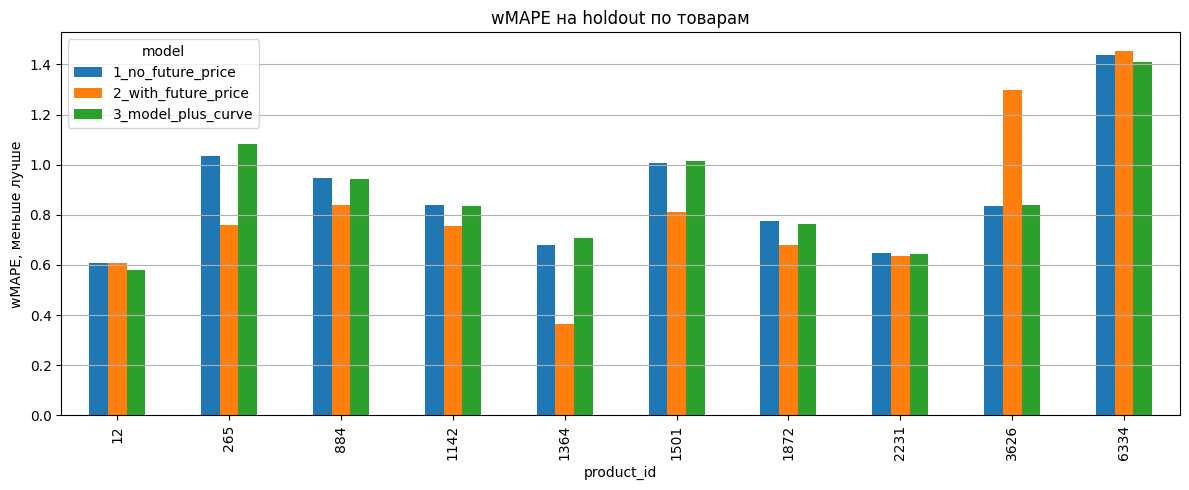

model,1_no_future_price,2_with_future_price,3_model_plus_curve
product_id,,,
12,0.608970,0.609697,0.581437
265,1.036420,0.757969,1.082361
884,0.947738,0.837554,0.942279
1142,0.839773,0.754468,0.836722
1364,0.679489,0.364708,0.706732
1501,1.005871,0.810464,1.014156
1872,0.775253,0.677758,0.763328
2231,0.649679,0.634638,0.644671
3626,0.834378,1.299776,0.839166


In [5]:

hw_per_product_metrics = []
for product_id, product_test in hw_test.groupby('product_id'):
    for model_name, pred_col in [
        ('1_no_future_price', 'pred_no_future_price'),
        ('2_with_future_price', 'pred_with_future_price'),
        ('3_model_plus_curve', 'pred_model_plus_curve')
    ]:
        row = forecast_metrics(product_test['sales_units'], product_test[pred_col]).to_dict()
        row.update({'product_id': product_id, 'model': model_name})
        hw_per_product_metrics.append(row)

hw_per_product_metrics = pd.DataFrame(hw_per_product_metrics)
hw_per_product_wmape = hw_per_product_metrics.pivot(
    index='product_id', columns='model', values='wMAPE'
)

fig, ax = plt.subplots(1, figsize=(12, 5))
hw_per_product_wmape.plot(kind='bar', ax=ax)
ax.set_title('wMAPE на holdout по товарам')
ax.set_xlabel('product_id')
ax.set_ylabel('wMAPE, меньше лучше')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

hw_per_product_wmape


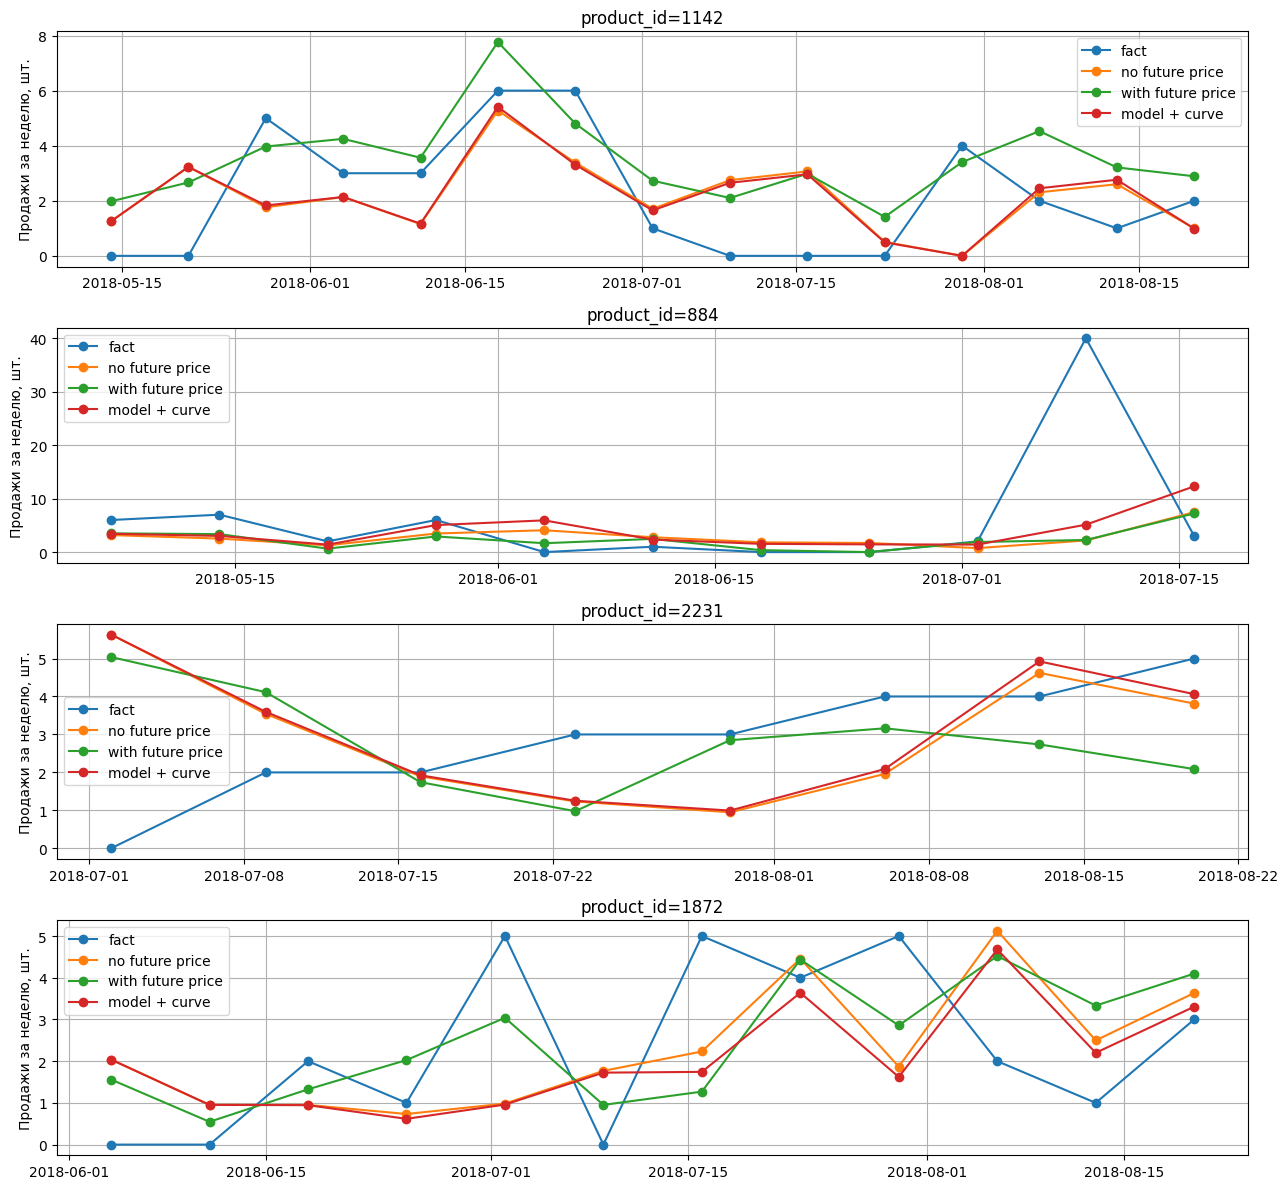

In [ ]:

# Несколько примеров факта и прогнозов во времени
plot_ids = selected_product_ids[:4]
fig, axes = plt.subplots(len(plot_ids), 1, figsize=(13, 3 * len(plot_ids)), sharex=False)
if len(plot_ids) == 1:
    axes = [axes]

for ax, product_id in zip(axes, plot_ids):
    d = hw_test.query('product_id == @product_id').sort_values('date')
    short_id = str(product_id)[:10]
    ax.plot(d['date'], d['sales_units'], marker='o', label='fact')
    ax.plot(d['date'], d['pred_no_future_price'], marker='o', label='no future price')
    ax.plot(d['date'], d['pred_with_future_price'], marker='o', label='with future price')
    ax.plot(d['date'], d['pred_model_plus_curve'], marker='o', label='model + curve')
    ax.set_title(f'product_id={short_id}')
    ax.set_ylabel('Продажи за неделю, шт.')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


## Итоговый вывод

В финальную выборку попали 10 товаров, которые проходят фильтры: 15+ активных недель, 10+ разных цен и 20+ продаж. По эластичности выборка получилась разной: 4 товара с сильной отрицательной эластичностью, 3 товара с умеренной отрицательной эластичностью и 3 товара с положительной или шумной связью цены и спроса.

По промо картина такая.

- Товары с эластичностью ниже -1 выглядят кандидатами для промо. Скидка должна заметно двигать спрос. Но экстремальные оценки вроде -25 я бы не использовал напрямую: это сигнал, что история короткая или цена менялась вместе с другими факторами.
- Товары с умеренно отрицательной эластичностью лучше тестировать аккуратно. Тут легко отдать маржу, но не получить нужный прирост штук.
- Товары с положительной или почти нулевой связью я бы не называл «товарами, где цена повышает спрос». Скорее всего, в данных смешались сезонность, остатки, маркетинг или решения продавца. Такие позиции безопаснее вести через регулярную цену и отдельный эксперимент.

По прогнозам сравниваю три значения wMAPE в таблице hw_overall_metrics. В текущем запуске лучше сработал бустинг с ценовыми признаками: будущая цена добавляет полезный сигнал. Вариант model_plus_curve полезен как интерпретируемая проверка, но он проигрывает прямой модели с ценовыми признаками: одна log-log кривая слишком грубо описывает поведение товара, а часть оценок эластичности нестабильна из-за короткой истории.

Историческая цена эндогенна: продавец мог менять ее из-за спроса, остатков, конкуренции или промо. Поэтому оценку эластичности здесь нельзя трактовать как чистый причинный эффект цены.

Что я бы улучшил дальше:

- добавить признаки промо, доставки, остатков, праздников и трафика
- оценивать эластичность с поддержкой категории, чтобы редкие товары не давали дикие коэффициенты
- проверять эффект цены через A/B-тест
